In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in [cwd, *cwd.parents] if (p / "scripts").exists() and (p / "pars").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("No se encontró la raíz del proyecto (faltan scripts/ y pars/).")
os.chdir(PROJECT_ROOT)
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from forward import *
from utils import *

In [3]:
# Cargar los datos del archivo mls.xy
data_path = r'C:\Users\PC\Documents\GitHub\GPT\data\py4cats\mls.xy'

# Leer el archivo manualmente para evitar problemas con comentarios
z, pressure, temperature, H2O, CO2, O3, N2O, CO, CH4, N2, O2 = [], [], [], [], [], [], [], [], [], [], []

with open(data_path, 'r') as f:
    lines = f.readlines()
    for line in lines[3:]:  # Saltar las 3 primeras líneas de header
        line = line.strip()
        if not line or line.startswith('#'):  # Saltar líneas vacías y comentarios
            continue
        try:
            values = line.split()
            z.append(float(values[0]))
            pressure.append(float(values[1]))
            temperature.append(float(values[2]))
            H2O.append(float(values[3]))
            CO2.append(float(values[4]))
            O3.append(float(values[5]))
            N2O.append(float(values[6]))
            CO.append(float(values[7]))
            CH4.append(float(values[8]))
            N2.append(float(values[9]))
            O2.append(float(values[10]))
        except (IndexError, ValueError):
            pass

# Crear DataFrame
data = pd.DataFrame({
    'z': z, 'pressure': pressure, 'temperature': temperature,
    'H2O': H2O, 'CO2': CO2, 'O3': O3, 'N2O': N2O,
    'CO': CO, 'CH4': CH4, 'N2': N2, 'O2': O2
})

print(f"Datos cargados: {data.shape[0]} altitudes")
print(f"\nPrimeras filas:")
print(data.head())
print(f"\nÚltimas filas:")
print(data.tail())

Datos cargados: 50 altitudes

Primeras filas:
     z   pressure  temperature       H2O      CO2            O3           N2O  \
0  0.0  1013000.0        294.2  0.018760  0.00033  3.017000e-08  3.200000e-07   
1  1.0   902000.0        289.7  0.013780  0.00033  3.337000e-08  3.200000e-07   
2  2.0   802000.0        285.2  0.009680  0.00033  3.694000e-08  3.200000e-07   
3  3.0   710000.0        279.2  0.005984  0.00033  4.222000e-08  3.200000e-07   
4  4.0   628000.0        273.2  0.003813  0.00033  4.821000e-08  3.200000e-07   

             CO       CH4     N2        O2  
0  1.500000e-07  0.000002  0.781  209000.0  
1  1.450000e-07  0.000002  0.781  209000.0  
2  1.399000e-07  0.000002  0.781  209000.0  
3  1.349000e-07  0.000002  0.781  209000.0  
4  1.312000e-07  0.000002  0.781  209000.0  

Últimas filas:
        z  pressure  temperature           H2O       CO2            O3  \
45  100.0    0.2580        190.5  4.000000e-07  0.000195  4.000000e-07   
46  105.0    0.1170        222.2 

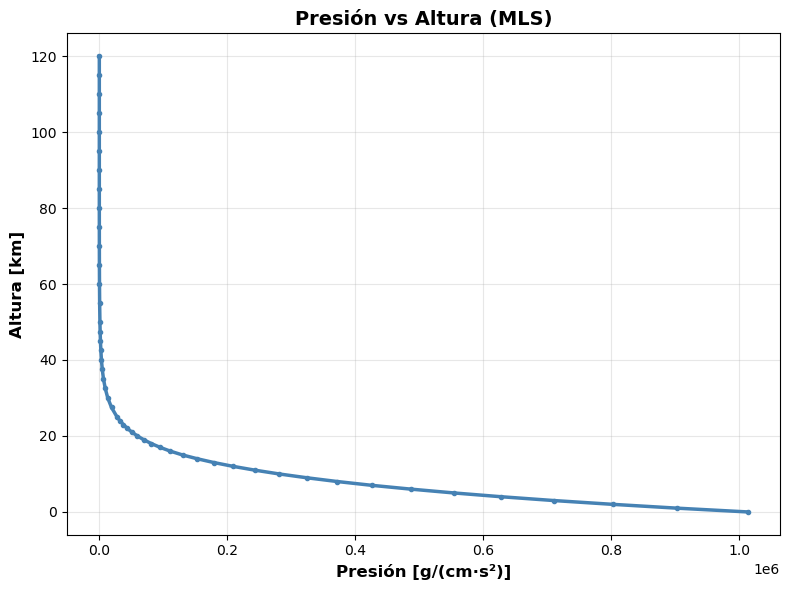

In [145]:
# Plot 1: Presión respecto a la altura (z)
fig_size = (8, 6)    
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(data['pressure'], data['z'], linewidth=2.5, color='steelblue', marker='o', markersize=3)
ax.set_xlabel('Presión [g/(cm·s²)]', fontsize=12, fontweight='bold')
ax.set_ylabel('Altura [km]', fontsize=12, fontweight='bold')
ax.set_title('Presión vs Altura (MLS)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

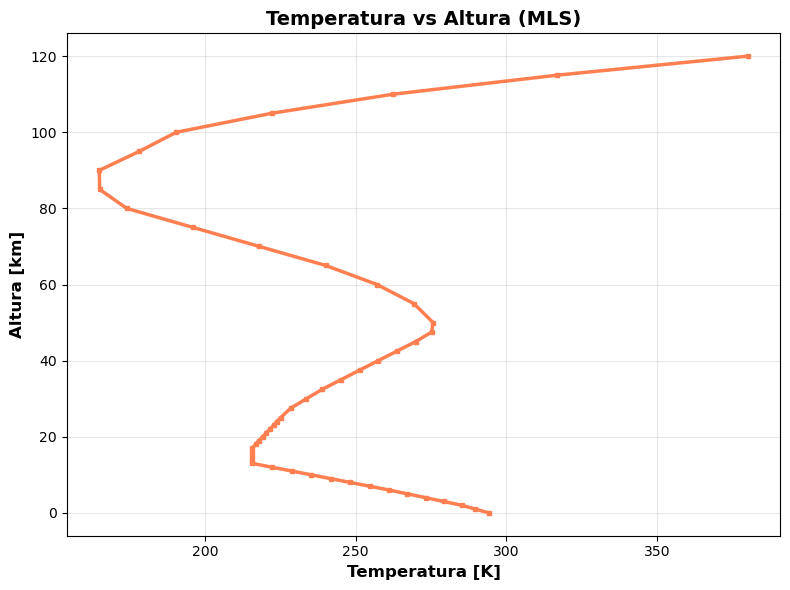

In [146]:
# Plot 2: Temperatura respecto a la altura (z)
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(data['temperature'], data['z'], linewidth=2.5, color='coral', marker='s', markersize=3)
ax.set_xlabel('Temperatura [K]', fontsize=12, fontweight='bold')
ax.set_ylabel('Altura [km]', fontsize=12, fontweight='bold')
ax.set_title('Temperatura vs Altura (MLS)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

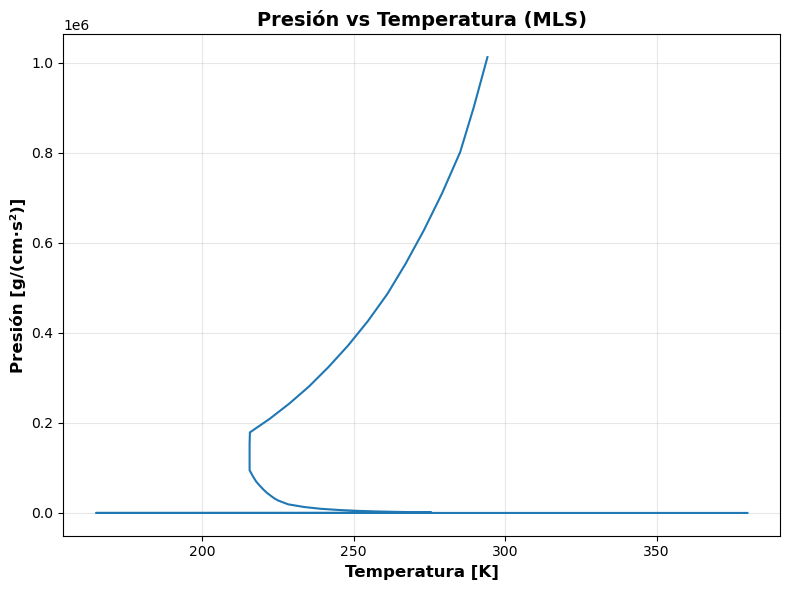

In [147]:
# Plot 4: Relación entre Presión y Temperatura
fig, ax = plt.subplots(figsize=fig_size)
ax.plot( data['temperature'].values,data['pressure'])
ax.set_xlabel('Temperatura [K]', fontsize=12, fontweight='bold')
ax.set_ylabel('Presión [g/(cm·s²)]', fontsize=12, fontweight='bold')
ax.set_title('Presión vs Temperatura (MLS)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# FUNCIONES ESTANDARIZADAS PARA ANÁLISIS DE ARCHIVOS Py4CATs

import os
from pathlib import Path

def cargar_archivo_xy(filepath):
    """
    Carga un archivo .xy de Py4CATs y retorna arrays numpy de todas sus columnas.
    
    Parámetros:
    -----------
    filepath : str
        Ruta al archivo .xy
    
    Retorna:
    --------
    dict : Diccionario con arrays numpy para cada columna
           Las columnas identificadas son: z, pressure, temperature, H2O, CO2, O3, N2O, CO, CH4, N2, O2
    bool : True si carga exitosa, False si hay error
    str : Mensaje de estado
    """
    try:
        # Columnas esperadas
        col_names = ['z', 'pressure', 'temperature', 'H2O', 'CO2', 'O3', 'N2O', 'CO', 'CH4', 'N2', 'O2']
        data_dict = {col: [] for col in col_names}
        
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        # Saltar líneas de encabezado y comentarios
        for line in lines[3:]:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            try:
                values = line.split()
                if len(values) >= 11:  # Asegurar suficientes columnas
                    for i, col in enumerate(col_names):
                        data_dict[col].append(float(values[i]))
            except (IndexError, ValueError):
                pass
        
        # Convertir lists a numpy arrays
        for col in col_names:
            data_dict[col] = np.array(data_dict[col])
        
        # Validar que hay datos
        if len(data_dict['z']) == 0:
            return None, False, f"No se encontraron datos válidos en {filepath}"
        
        # Validar integridad
        n_puntos = len(data_dict['z'])
        for col in col_names:
            if len(data_dict[col]) != n_puntos:
                return None, False, f"Error: columnas con longitudes diferentes en {filepath}"
        
        return data_dict, True, f"✓ Cargado {filepath}: {n_puntos} puntos"
    
    except Exception as e:
        return None, False, f"✗ Error al cargar {filepath}: {str(e)}"


def analizar_relacion_pt(data_dict, nombre_archivo=""):
    """
    Realiza un análisis completo de la relación entre Presión y Temperatura.
    
    Parámetros:
    -----------
    data_dict : dict
        Diccionario con arrays numpy (resultado de cargar_archivo_xy)
    nombre_archivo : str
        Nombre del archivo para identificación en el reporte
    
    Retorna:
    --------
    dict : Diccionario con resultados del análisis
    """
    z_arr = data_dict['z']
    p_arr = data_dict['pressure']
    T_arr = data_dict['temperature']
    
    # Correlación global
    corr_global = np.corrcoef(p_arr, T_arr)[0, 1]
    
    # Derivadas numéricas
    dp_dz = np.gradient(p_arr, z_arr)
    dT_dz = np.gradient(T_arr, z_arr)
    
    # Análisis por capas
    results = {
        'archivo': nombre_archivo,
        'n_puntos': len(z_arr),
        'z_rango': (z_arr.min(), z_arr.max()),
        'p_rango': (p_arr.min(), p_arr.max()),
        'T_rango': (T_arr.min(), T_arr.max()),
        'H2O_rango': (data_dict['H2O'].min(), data_dict['H2O'].max()),
        'O3_rango': (data_dict['O3'].min(), data_dict['O3'].max()),
        'N2O_rango': (data_dict['N2O'].min(), data_dict['N2O'].max()),
        'CO_rango': (data_dict['CO'].min(), data_dict['CO'].max()),
        'CH4_rango': (data_dict['CH4'].min(), data_dict['CH4'].max()),
        'N2_rango': (data_dict['N2'].min(), data_dict['N2'].max()),
        'O2_rango': (data_dict['O2'].min(), data_dict['O2'].max()),
        'T_celsius_rango': (T_arr.min()-273.15, T_arr.max()-273.15),
        'correlacion_global': corr_global,
    }
    
    # Troposfera
    tropo = z_arr <= 12
    if tropo.sum() > 1:
        p_t, T_t = p_arr[tropo], T_arr[tropo]
        results['tropo_corr'] = np.corrcoef(p_t, T_t)[0, 1]
        results['tropo_pendiente'] = (T_t[-1] - T_t[0]) / (p_t[-1] - p_t[0]) if p_t[-1] != p_t[0] else 0
    else:
        results['tropo_corr'] = None
        results['tropo_pendiente'] = None
    
    # Estratosfera
    strato = (z_arr > 12) & (z_arr <= 50)
    if strato.sum() > 1:
        p_s, T_s = p_arr[strato], T_arr[strato]
        results['strato_corr'] = np.corrcoef(p_s, T_s)[0, 1]
        results['strato_pendiente'] = (T_s[-1] - T_s[0]) / (p_s[-1] - p_s[0]) if p_s[-1] != p_s[0] else 0
    else:
        results['strato_corr'] = None
        results['strato_pendiente'] = None
    
    # Mesosfera
    meso = z_arr > 50
    if meso.sum() > 1:
        p_m, T_m = p_arr[meso], T_arr[meso]
        results['meso_corr'] = np.corrcoef(p_m, T_m)[0, 1]
        results['meso_pendiente'] = (T_m[-1] - T_m[0]) / (p_m[-1] - p_m[0]) if p_m[-1] != p_m[0] else 0
    else:
        results['meso_corr'] = None
        results['meso_pendiente'] = None
    
    # Lapse rate
    lapse_rate = -dT_dz
    results['lapse_rate_medio'] = np.nanmean(lapse_rate)
    results['dp_dz_rango'] = (dp_dz.min(), dp_dz.max())
    results['dT_dz_rango'] = (dT_dz.min(), dT_dz.max())
    
    return results


In [45]:

# Listar todos los archivos .xy
carpeta_py4cats = r'C:\Users\PC\Documents\GitHub\GPT\data\Py4CATs'
archivos_xy = sorted([f for f in os.listdir(carpeta_py4cats) if f.endswith('.xy')])

print("="*80)
print("ANÁLISIS COMPARATIVO DE TODOS LOS ARCHIVOS Py4CATs")
print("="*80)
print(f"\nArchivos encontrados: {len(archivos_xy)}")
for i, arch in enumerate(archivos_xy, 1):
    print(f"  {i:2d}. {arch}")

# Cargar todos los archivos y almacenar resultados
print("\n" + "="*80)
print("CARGANDO DATOS...")
print("="*80)

datos_todos = {}
resultados_todos = {}

for archivo in archivos_xy:
    filepath = os.path.join(carpeta_py4cats, archivo)
    datos, exito, mensaje = cargar_archivo_xy(filepath)
    
    if exito:
        datos_todos[archivo] = datos
        resultados_todos[archivo] = analizar_relacion_pt(datos, archivo)
        print(mensaje)
    else:
        print(mensaje)

print(f"\n✓ Se cargaron exitosamente {len(datos_todos)}/{len(archivos_xy)} archivos")


ANÁLISIS COMPARATIVO DE TODOS LOS ARCHIVOS Py4CATs

Archivos encontrados: 6
   1. mls.xy
   2. mlw.xy
   3. sas.xy
   4. saw.xy
   5. tro.xy
   6. uss.xy

CARGANDO DATOS...
✓ Cargado C:\Users\PC\Documents\GitHub\GPT\data\Py4CATs\mls.xy: 50 puntos
✓ Cargado C:\Users\PC\Documents\GitHub\GPT\data\Py4CATs\mlw.xy: 50 puntos
✓ Cargado C:\Users\PC\Documents\GitHub\GPT\data\Py4CATs\sas.xy: 50 puntos
✓ Cargado C:\Users\PC\Documents\GitHub\GPT\data\Py4CATs\saw.xy: 50 puntos
✓ Cargado C:\Users\PC\Documents\GitHub\GPT\data\Py4CATs\tro.xy: 50 puntos
✓ Cargado C:\Users\PC\Documents\GitHub\GPT\data\Py4CATs\uss.xy: 50 puntos

✓ Se cargaron exitosamente 6/6 archivos


In [116]:
# ANÁLISIS COMPARATIVO COMPLETO

export_lines = []
export_lines.append("Rangos")
export_lines.append("="*230)
export_lines.append(f"{'Modelo':<10} {'Puntos':<8} {'Z (km)':<15} {'P (g/cm·s²)':<20} {'T (K)':<20} {'H2O (ppV)':<22} {'O3 (ppV)':<22} {'N2O (ppV)':<22} {'CO (ppV)':<22} {'CH4 (ppV)':<22} {'N2 (ppV)':<22} {'O2 (ppV)':<25}")
export_lines.append("-"*230)

for archivo in sorted(resultados_todos.keys()):
    res = resultados_todos[archivo]
    nombre = archivo.replace('.xy', '')
    z_min, z_max = res['z_rango']
    p_min, p_max = res['p_rango']
    T_min, T_max = res['T_rango']
    H2O_min, H2O_max = res['H2O_rango']
    O3_min, O3_max = res['O3_rango']
    N2O_min, N2O_max = res['N2O_rango']
    CO_min, CO_max = res['CO_rango']
    CH4_min, CH4_max = res['CH4_rango']
    N2_min, N2_max = res['N2_rango']
    O2_min, O2_max = res['O2_rango']

    export_line = (f"{nombre:<10} {res['n_puntos']:<8} {z_min:.0f}-{z_max:.0f} km      "
                   f"{p_min:.2e}-{p_max:.2e}   {T_min:.1f}-{T_max:.1f} K      "
                   f"{H2O_min:.2e}-{H2O_max:.2e}      {O3_min:.2e}-{O3_max:.2e}      "
                   f"{N2O_min:.2e}-{N2O_max:.2e}      {CO_min:.2e}-{CO_max:.2e}      "
                   f"{CH4_min:.2e}-{CH4_max:.2e}      {N2_min:.2e}-{N2_max:.2e}      {O2_min:.2e}-{O2_max:.2e}")
    export_lines.append(export_line)

export_lines.append("\n")
export_lines.append("Correlación por capas")
export_lines.append("="*60)
export_lines.append(f"{'Modelo':<10} {'Troposfera':<15} {'Estratosfera':<15} {'Mesosfera':<15}")
export_lines.append("-"*60)

for archivo in sorted(resultados_todos.keys()):
    res = resultados_todos[archivo]
    tropo = res['tropo_corr']
    strato = res['strato_corr']
    meso = res['meso_corr']
    
    tropo_str = f"{tropo:.4f}" if tropo is not None and not np.isnan(tropo) else "N/A"
    strato_str = f"{strato:.4f}" if strato is not None and not np.isnan(strato) else "N/A"
    meso_str = f"{meso:.4f}" if meso is not None and not np.isnan(meso) else "N/A"
    
    export_lines.append(f"{archivo[:-3]:<10} {tropo_str:<15} {strato_str:<15} {meso_str:<15}")


correlaciones = [resultados_todos[arch]['correlacion_global'] for arch in resultados_todos.keys() 
                 if not np.isnan(resultados_todos[arch]['correlacion_global'])]
lapse_rates = [resultados_todos[arch]['lapse_rate_medio'] for arch in resultados_todos.keys()
               if not np.isnan(resultados_todos[arch]['lapse_rate_medio'])]


# Contar estabilidades
estables = sum(1 for lr in lapse_rates if lr < 0.0065)
inestables = len(lapse_rates) - estables

# Agregar tabla de P-T en troposfera
export_lines.append("\n")
export_lines.append("Relación Presión-Temperatura en TROPOSFERA (0-12 km)")
export_lines.append("="*110)
export_lines.append(f"{'Modelo':<10} {'P_min':<18} {'P_max':<18} {'P_prom':<18} {'T_min (K)':<15} {'T_max (K)':<15} {'T_prom (K)':<15}")
export_lines.append("-"*110)

# Calcular promedios para la fila de resumen
p_prom_total = []
T_prom_total = []

for archivo in sorted(resultados_todos.keys()):
    datos = datos_todos[archivo]
    z_arr = datos['z']
    p_arr = datos['pressure']
    T_arr = datos['temperature']
    
    # Filtrar solo troposfera (z <= 12 km)
    tropo_mask = z_arr <= 12
    if tropo_mask.sum() > 0:
        p_tropo = p_arr[tropo_mask]
        T_tropo = T_arr[tropo_mask]
        
        p_min, p_max = p_tropo.min(), p_tropo.max()
        p_prom = np.mean(p_tropo)
        T_min, T_max = T_tropo.min(), T_tropo.max()
        T_prom = np.mean(T_tropo)
        
        p_prom_total.append(p_prom)
        T_prom_total.append(T_prom)
        
        nombre = archivo.replace('.xy', '')
        export_line = f"{nombre:<10}{p_min:.2e}           {p_max:.2e}            {p_prom:.2e}             {T_min:.1f}           {T_max:.1f}           {T_prom:.1f}"
        export_lines.append(export_line)


# Exportar a archivo
output_path = r'C:\Users\PC\Documents\GitHub\GPT\data\rango_py4cats.txt'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(export_lines))

print("\n" + "="*80)
print(f"✓ Tabla exportada exitosamente a: {output_path}")
print("="*80)


✓ Tabla exportada exitosamente a: C:\Users\PC\Documents\GitHub\GPT\data\rango_py4cats.txt


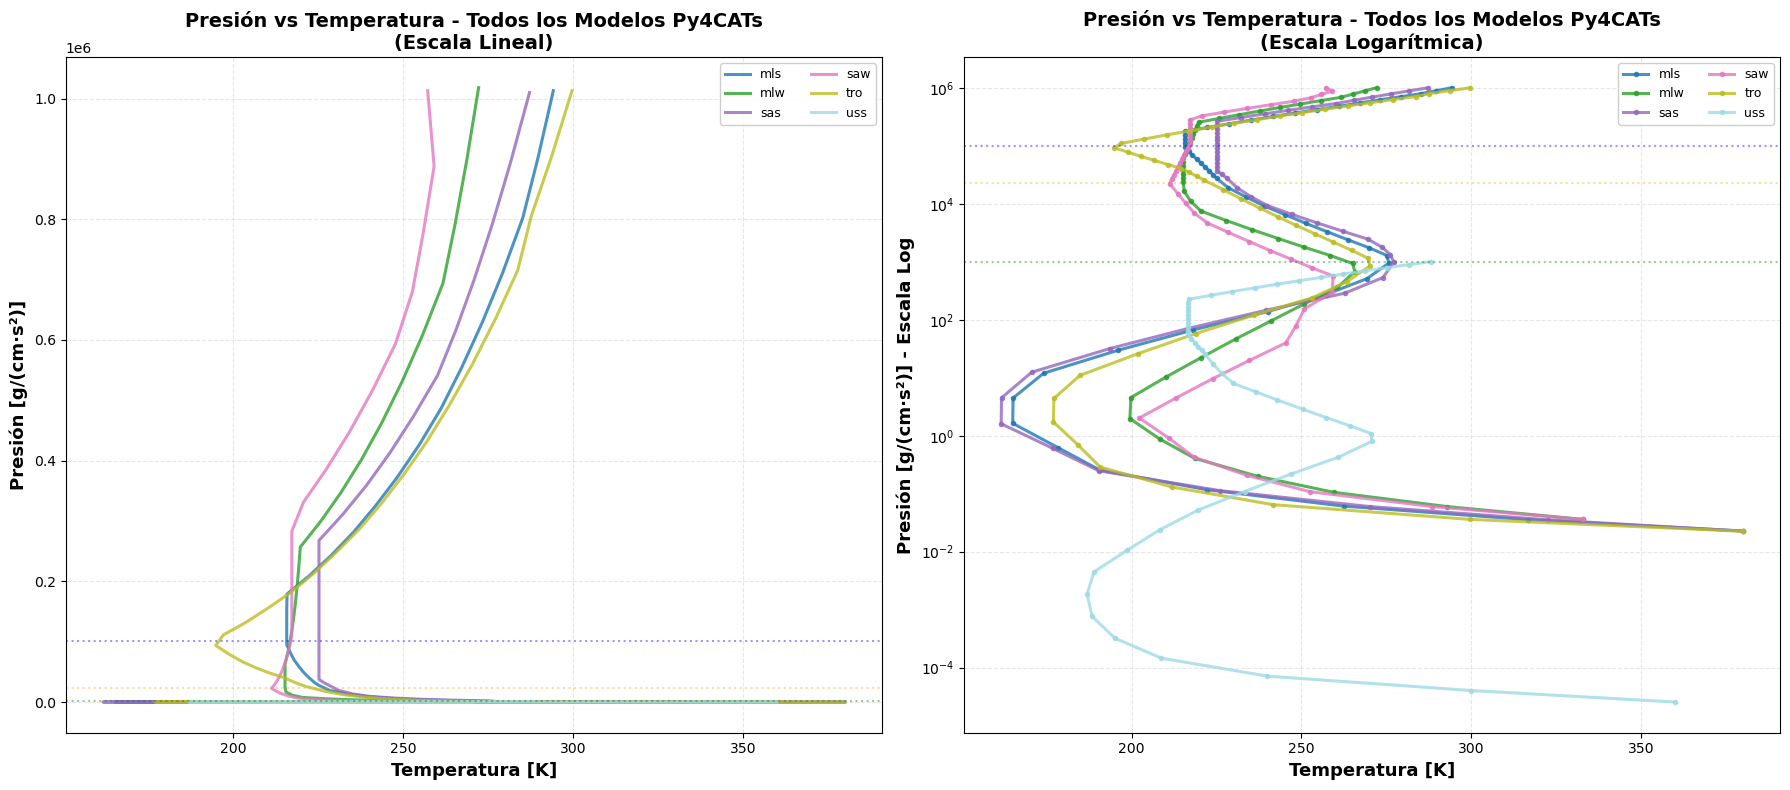

In [148]:
archivos_sorted = sorted(datos_todos.keys())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
colors_palette = plt.cm.tab20(np.linspace(0, 1, len(archivos_sorted)))

# GRÁFICO 1: Presión vs Temperatura (ESCALA LINEAL)
for idx, archivo in enumerate(archivos_sorted):
    datos = datos_todos[archivo]
    nombre = archivo.replace('.xy', '').replace('_', ' ')
    
    ax1.plot(datos['temperature'], datos['pressure'], 
             linewidth=2.2, label=nombre, color=colors_palette[idx], alpha=0.8)

ax1.set_xlabel('Temperatura [K]', fontsize=13, fontweight='bold')
ax1.set_ylabel('Presión [g/(cm·s²)]', fontsize=13, fontweight='bold')
ax1.set_title('Presión vs Temperatura - Todos los Modelos Py4CATs\n(Escala Lineal)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

# GRÁFICO 2: Presión vs Temperatura (ESCALA LOGARÍTMICA en P)
for idx, archivo in enumerate(archivos_sorted):
    datos = datos_todos[archivo]
    nombre = archivo.replace('.xy', '').replace('_', ' ')
    
    # Filtrar presiones > 0 para escala log
    mask = datos['pressure'] > 0
    ax2.semilogy(datos['temperature'][mask], datos['pressure'][mask], 
                 linewidth=2.2, label=nombre, color=colors_palette[idx], alpha=0.8, marker='o', markersize=3)

ax2.set_xlabel('Temperatura [K]', fontsize=13, fontweight='bold')
ax2.set_ylabel('Presión [g/(cm·s²)] - Escala Log', fontsize=13, fontweight='bold')
ax2.set_title('Presión vs Temperatura - Todos los Modelos Py4CATs\n(Escala Logarítmica)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', which='both')
ax2.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

# Agregar líneas de referencia de capas atmosféricas
for ax in [ax1, ax2]:
    ax.axhline(y=1.01e5, color='blue', linestyle=':', linewidth=1.5, alpha=0.4, label='Nivel del mar')
    ax.axhline(y=2.3e4, color='orange', linestyle=':', linewidth=1.5, alpha=0.4, label='Tropo/Estrato (12 km)')
    ax.axhline(y=1000, color='green', linestyle=':', linewidth=1.5, alpha=0.4, label='Estrato/Meso (50 km)')

plt.tight_layout()
plt.show()


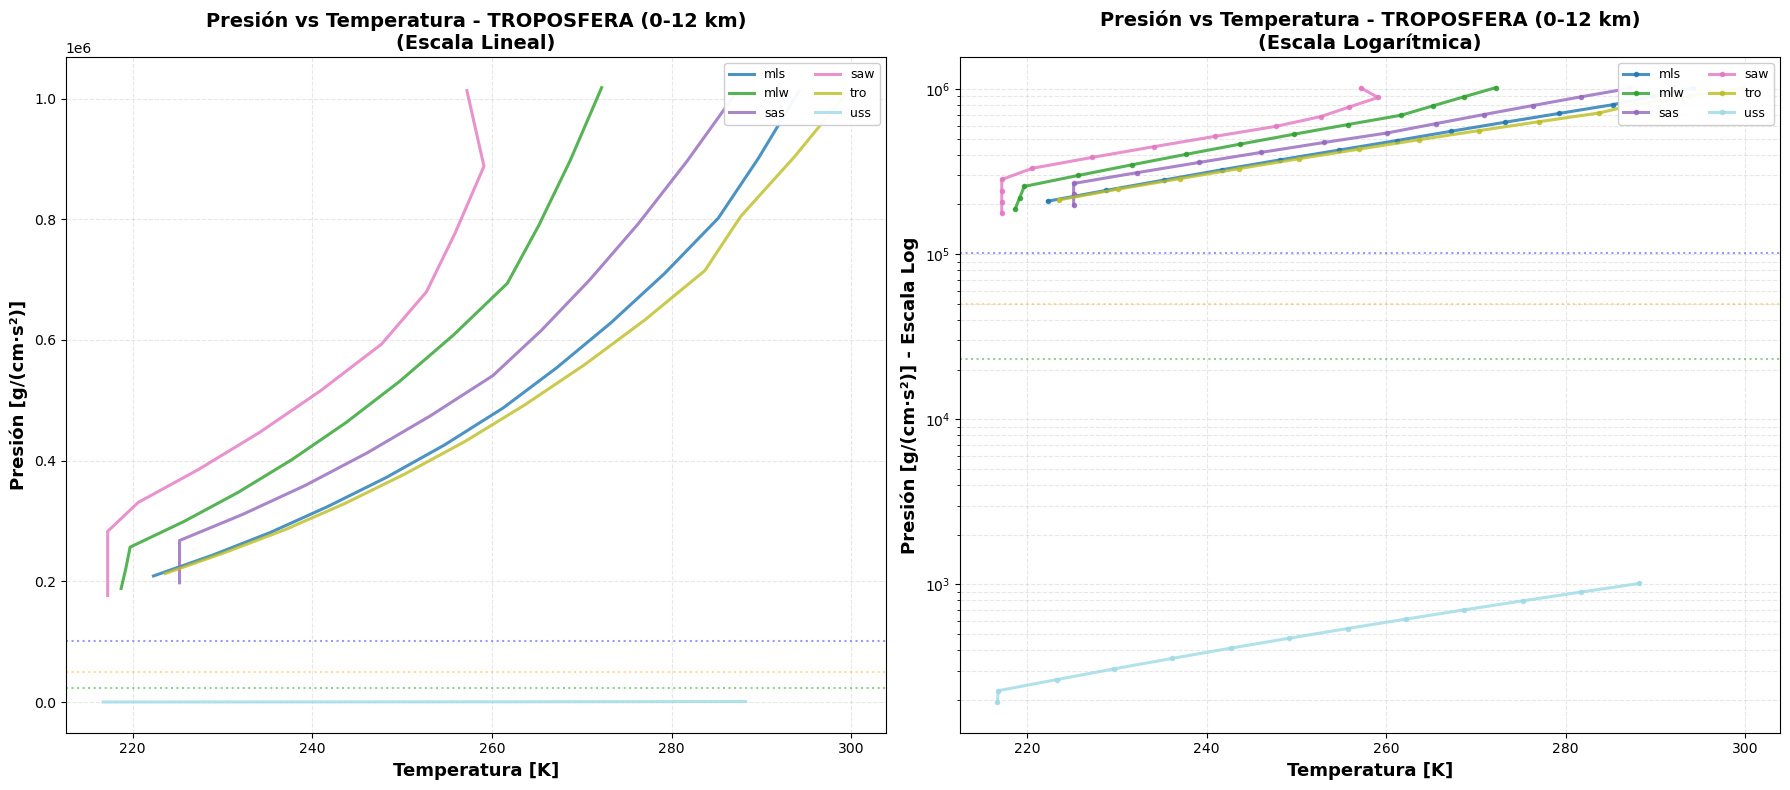

In [143]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
colors_palette = plt.cm.tab20(np.linspace(0, 1, len(archivos_sorted)))

# GRÁFICO 1: Presión vs Temperatura - TROPOSFERA (ESCALA LINEAL)
for idx, archivo in enumerate(archivos_sorted):
    datos = datos_todos[archivo]
    z_arr = datos['z']
    tropo_mask = z_arr <= 12
    if tropo_mask.sum() > 0:
        T_tropo = datos['temperature'][tropo_mask]
        p_tropo = datos['pressure'][tropo_mask]
        nombre = archivo.replace('.xy', '').replace('_', ' ')
        ax1.plot(T_tropo, p_tropo,
                 linewidth=2.2, label=nombre, color=colors_palette[idx], alpha=0.8)

ax1.set_xlabel('Temperatura [K]', fontsize=13, fontweight='bold')
ax1.set_ylabel('Presión [g/(cm·s²)]', fontsize=13, fontweight='bold')
ax1.set_title('Presión vs Temperatura - TROPOSFERA (0-12 km)\n(Escala Lineal)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

# GRÁFICO 2: Presión vs Temperatura - TROPOSFERA (ESCALA LOGARÍTMICA en P)
for idx, archivo in enumerate(archivos_sorted):
    datos = datos_todos[archivo]
    z_arr = datos['z']
    tropo_mask = z_arr <= 12
    if tropo_mask.sum() > 0:
        T_tropo = datos['temperature'][tropo_mask]
        p_tropo = datos['pressure'][tropo_mask]
        nombre = archivo.replace('.xy', '').replace('_', ' ')
        mask = p_tropo > 0
        ax2.semilogy(T_tropo[mask], p_tropo[mask],
                     linewidth=2.2, label=nombre, color=colors_palette[idx], alpha=0.8, marker='o', markersize=3)

ax2.set_xlabel('Temperatura [K]', fontsize=13, fontweight='bold')
ax2.set_ylabel('Presión [g/(cm·s²)] - Escala Log', fontsize=13, fontweight='bold')
ax2.set_title('Presión vs Temperatura - TROPOSFERA (0-12 km)\n(Escala Logarítmica)', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--', which='both')
ax2.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)

# Líneas de referencia troposféricas
for ax in [ax1, ax2]:
    ax.axhline(y=1.01e5, color='blue', linestyle=':', linewidth=1.5, alpha=0.4)
    ax.axhline(y=5e4, color='orange', linestyle=':', linewidth=1.5, alpha=0.4)
    ax.axhline(y=2.3e4, color='green', linestyle=':', linewidth=1.5, alpha=0.4)

plt.tight_layout()
plt.show()